# 5. Backtesting

Before committing to the 2026 portfolio weights, this chapter answers two
questions using the completed FY25 tax year as the test bed:

1. **How did the 2025 portfolio actually perform?** — [TWR](../content/99_glossary.md#return-metrics),
   [MWR](../content/99_glossary.md#future-metrics-not-yet-in-the-book), drawdown and professional
   risk metrics over the full financial year (5 Apr 2025 → 4 Apr 2026),
   driven by the real InvestEngine trade ledger.

2. **Would adding precious metals and commodities have helped?** — A
   counterfactual showing how the 2026 weights (which add a 5% gold sleeve
   and 10% commodity sleeve) would have behaved across the same FY25 window.

The backtest does **not** recalibrate the weights with hindsight — both
portfolios use their live, out-of-sample target allocations.

Live forward P&L for the ongoing 2026 portfolio lives in the
[Performance Tracking](04_performance_tracking.ipynb) chapter.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from etf_utils.config import RISK_FREE_RATE, PROJECT_ROOT
from etf_utils.data_provider import DataProvider
from etf_utils.database import (
    load_portfolio,
    save_rebalancing_trades,
    load_rebalancing_trades,
)
from etf_utils.backtesting import (
    Backtester,
    parse_investengine_statement,
    dynamic_portfolio_return,
    rolling_avg_pairwise_corr,
    rolling_constituent_beta,
    period_metrics_table,
)
from etf_utils.metrics import (
    calculate_beta,
    calculate_information_ratio,
    calculate_max_drawdown,
    calculate_sharpe_ratio,
    calculate_tracking_error,
    rolling_sharpe,
    rolling_volatility_from_cumret,
)

# UK financial-year 2025-26 — the window every section in this notebook uses.
FY25_START = pd.Timestamp("2025-04-05")
FY25_END   = pd.Timestamp("2026-04-04")
FY25_BDAYS = len(pd.bdate_range(FY25_START, FY25_END))

provider = DataProvider()
portfolio_25 = load_portfolio(year=2025)
print(f"Loaded 2025 portfolio: {len(portfolio_25)} positions, "
      f"{portfolio_25['asset_class'].nunique()} asset classes.")
print(f"Backtest window: {FY25_START.date()} → {FY25_END.date()} "
      f"({FY25_BDAYS} business days).")


Loaded 2025 portfolio: 16 positions, 2 asset classes.
Backtest window: 2025-04-05 → 2026-04-04 (260 business days).


## 1. FY25 actual portfolio backtest

The 2025 portfolio held equities and bonds only. This section replays every
real trade from the InvestEngine statement to produce a
[TWR](../content/99_glossary.md#return-metrics) that chains sub-period returns across
each rebalance event. Three questions are answered in sequence:

- What was the total return, and how much came from income vs price movement?
- Did rebalancing help or hurt vs a simple buy-and-hold?
- How does the portfolio compare to a fixed-weight blended benchmark on
  professional risk-adjusted metrics?

### 1.1 Trade loading and backtest window

Window: **5 Apr 2025 → 4 Apr 2026** (UK financial year 2025-26, 260 business
days). Trades are loaded from the InvestEngine statement CSV; if the CSV is
absent, the previously persisted trades are loaded from the database.

In [2]:
statement_path = (
    PROJECT_ROOT / "data" / "investment_statements" / "RebalancingTrades2025.csv"
)

if statement_path.exists():
    trades = parse_investengine_statement(statement_path)
    save_rebalancing_trades(trades, portfolio_year=2025)
    print(f"Parsed {len(trades)} trades from CSV and saved to DB.")
else:
    trades = load_rebalancing_trades(portfolio_year=2025)
    if trades.empty:
        raise FileNotFoundError(
            f"No trading statement at {statement_path} and no trades in DB "
            f"for year 2025."
        )
    trades["trade_date"] = pd.to_datetime(trades["trade_date"])
    print(f"Loaded {len(trades)} trades from DB.")

print(f"Date range: {trades['trade_date'].min().date()} → "
      f"{trades['trade_date'].max().date()}")
print(f"Tickers: {trades['ticker'].nunique()}")

bt = Backtester.from_trades(trades, provider, end_date=FY25_END)
price_data = bt.price_data
all_tickers = sorted(price_data.keys())
rebalance_dates = sorted(trades["trade_date"].unique())
first_trade_date = bt.start_date

# Per-ticker share ledger and cost basis (used downstream)
share_ledger = defaultdict(float)
cost_basis = defaultdict(float)
for _, t in trades.iterrows():
    share_ledger[t["ticker"]] += t["signed_qty"]
    cost_basis[t["ticker"]] += t["signed_value"]
print(f"Share ledger built for {len(share_ledger)} tickers.")


Loaded 351 trades from DB.
Date range: 2025-05-12 → 2026-03-23
Tickers: 16
Share ledger built for 16 tickers.


### 1.2 Individual ETF returns

Per-ticker breakdown: the pure **adjusted-close price return** over FY25
alongside the **personal money-weighted return** based on the actual shares
bought at the actual trade prices. The two columns differ when the timing of
purchases captured (or missed) a price move.

In [3]:
first_day_trades = trades[trades["trade_date"] == first_trade_date]
initial_deposits = {}
for _, t in first_day_trades.iterrows():
    initial_deposits[t["ticker"]] = (
        initial_deposits.get(t["ticker"], 0) + t["signed_value"]
    )
total_initial_cash = sum(v for v in initial_deposits.values() if v > 0)

ticker_rows = []
for ticker in all_tickers:
    df = price_data[ticker]
    after_start = df[df.index >= first_trade_date]
    before_end = df[df.index <= FY25_END]
    if after_start.empty or before_end.empty:
        continue
    px_start = float(after_start["close"].iloc[0])
    px_end = float(before_end["close"].iloc[-1])
    price_ret = ((px_end / px_start) - 1) * 100

    net_cost = cost_basis.get(ticker, 0)
    shares = share_ledger.get(ticker, 0)
    current_val = shares * px_end if shares > 0 else 0
    my_ret = ((current_val - net_cost) / net_cost * 100) if net_cost > 0 else 0
    first_px = trades[trades["ticker"] == ticker].iloc[0]["price"]
    weight = (
        (initial_deposits.get(ticker, 0) / total_initial_cash * 100)
        if total_initial_cash > 0 else 0
    )

    ticker_rows.append({
        "Ticker": ticker,
        "Start": after_start.index[0].date(),
        "End": before_end.index[-1].date(),
        "Trade Px (£)": round(first_px, 2),
        "DP Start": round(px_start, 2),
        "DP End": round(px_end, 2),
        "Price Ret (%)": round(price_ret, 2),
        "My Ret (%)": round(my_ret, 2),
        "Weight (%)": round(weight, 1),
    })

df_tickers = pd.DataFrame(ticker_rows)
display(
    df_tickers[['Ticker', 'Trade Px (£)', 'Price Ret (%)', 'My Ret (%)', 'Weight (%)']]
    .style.format({
        'Trade Px (£)': '£{:.2f}',
        'Price Ret (%)': '{:+.2f}%',
        'My Ret (%)': '{:+.2f}%',
        'Weight (%)': '{:.1f}%',
    })
    .hide(axis='index')
)

Ticker,Trade Px (£),Price Ret (%),My Ret (%),Weight (%)
AUAD,£18.39,+15.91%,+12.40%,16.0%
EMCP,£68.33,+5.73%,-1.07%,1.0%
HMCH,£5.69,+4.07%,+1.47%,2.0%
IBZL,£16.84,+49.42%,+48.14%,8.0%
IGLT,£9.98,+2.72%,-1.54%,1.0%
IMIB,£20.43,+23.13%,+18.25%,18.0%
LCUK,£12.16,+19.41%,+19.82%,9.0%
PRIJ,£24.12,+20.07%,+21.68%,7.0%
PRIR,£14.52,+4.16%,+0.98%,3.0%
QYLP,£11.94,+13.81%,+1.95%,7.0%


### 1.3 Portfolio-level return: TWR vs MWR

- **[TWR](../content/99_glossary.md#return-metrics)** chains sub-period returns across
  every rebalance date, stripping out the effect of when cash was added.
  This is the *strategy* score.
- **[MWR](../content/99_glossary.md#future-metrics-not-yet-in-the-book)** divides ending
  portfolio value by total cash deposited. This is the *investor experience*
  score — it includes the timing luck of when deposits landed.

A large gap between the two tells you that contribution timing had a
meaningful impact on actual wealth outcomes.

In [4]:
actual_twr_series = bt.run_twr_series(trades)
total_twr = actual_twr_series.iloc[-1]

CASH_DEPOSITED = 20_000
total_trade_cost = sum(cost_basis.values())
estimated_dividends_reinvested = total_trade_cost - CASH_DEPOSITED

def _value_at(date):
    val = 0.0
    for t, shares in share_ledger.items():
        px = bt.get_price(t, date)
        if px:
            val += shares * px
    return val

total_current_value = _value_at(FY25_END)
mwr_return = (total_current_value / CASH_DEPOSITED - 1) * 100

summary_df = pd.DataFrame({
    "Metric": [
        "Time-Weighted Return (TWR)",
        "Money-Weighted Return (MWR)",
        "Net Cash Deposited",
        "Dividends Reinvested (est.)",
        "Portfolio Value @ FY25 End",
        "Absolute P&L (incl. dividends)",
    ],
    "Value": [
        f"{total_twr:.2f}%",
        f"{mwr_return:.2f}%",
        f"£{CASH_DEPOSITED:,.2f}",
        f"£{estimated_dividends_reinvested:,.2f}",
        f"£{total_current_value:,.2f}",
        f"£{total_current_value - CASH_DEPOSITED:,.2f}",
    ],
})
display(summary_df)


,Metric,Value
0,Time-Weighted Return (TWR),15.62%
1,Money-Weighted Return (MWR),15.46%
2,Net Cash Deposited,"£20,000.00"
3,Dividends Reinvested (est.),£760.29
4,Portfolio Value @ FY25 End,"£23,091.60"
5,Absolute P&L (incl. dividends),"£3,091.60"


### 1.3.1 Rebalancing impact

What would Day 1's lump sum be worth at FY25 end if no further trading had
ever occurred? Comparing this buy-and-hold counterfactual to the actual
[TWR](../content/99_glossary.md#return-metrics) isolates whether the rebalancing schedule
added or destroyed value over the year.

In [5]:
bnh_cost = 0
bnh_ticker_cost = {}
bnh_holdings = {}
for _, t in first_day_trades.iterrows():
    bnh_cost += t["signed_value"]
    bnh_ticker_cost[t["ticker"]] = (
        bnh_ticker_cost.get(t["ticker"], 0) + t["signed_value"]
    )
    bnh_holdings[t["ticker"]] = (
        bnh_holdings.get(t["ticker"], 0) + t["signed_qty"]
    )

bnh_series = bt.run_buy_and_hold_series(bnh_holdings)
bnh_total_return = bnh_series.iloc[-1]

bnh_price_only_val = 0
ticker_stats = []
for tkr, qty in bnh_holdings.items():
    px_start = bt.get_price(tkr, first_trade_date)
    px_end = bt.get_price(tkr, FY25_END)
    if px_start and px_end:
        bnh_price_only_val += qty * px_end
        ticker_stats.append({
            "Ticker": tkr,
            "Adj Start": round(px_start, 2),
            "Adj End": round(px_end, 2),
            "Total Return (%)": round(((px_end / px_start) - 1) * 100, 2),
        })

bnh_price_return = (bnh_price_only_val / bnh_cost - 1) * 100 if bnh_cost > 0 else 0
bnh_implied_dividends = bnh_total_return - bnh_price_return
bnh_estimated_value = bnh_cost * (1 + bnh_total_return / 100)

print("=" * 65)
print("REBALANCING IMPACT: Buy & Hold Counterfactual")
print("=" * 65)
print(f"Initial Investment (Day 1):       £{bnh_cost:,.2f}")
print(f"B&H Price-Only Return:            {bnh_price_return:.2f}%")
print(f"B&H Implied Dividends Reinvested: +{bnh_implied_dividends:.2f}%")
print(f"B&H Total Return (inc. divs):     {bnh_total_return:.2f}%")
print(f"B&H Est. Value (inc. divs):       £{bnh_estimated_value:,.2f}")
print()
print(f"Actual Portfolio Return (TWR):    {total_twr:.2f}%")
diff = total_twr - bnh_total_return
impact = "HELPED" if diff > 0 else "HURT (Drag)"
print(f"Net Rebalancing Impact:           {diff:+.2f}%  ({impact})")

print("\nPer-Ticker Buy & Hold Returns (adjusted for dividends):")
display(pd.DataFrame(ticker_stats).sort_values("Total Return (%)", ascending=False))


REBALANCING IMPACT: Buy & Hold Counterfactual
Initial Investment (Day 1):       £19,988.32
B&H Price-Only Return:            11.67%
B&H Implied Dividends Reinvested: +4.13%
B&H Total Return (inc. divs):     15.81%
B&H Est. Value (inc. divs):       £23,147.65

Actual Portfolio Return (TWR):    15.62%
Net Rebalancing Impact:           -0.19%  (HURT (Drag))

Per-Ticker Buy & Hold Returns (adjusted for dividends):


,Ticker,Adj Start,Adj End,Total Return (%)
2,IBZL,15.72,23.48,49.42
1,IMIB,19.61,24.14,23.13
13,PRIJ,24.17,29.02,20.07
15,LCUK,12.19,14.55,19.41
7,AUAD,17.79,20.62,15.91
14,QYLP,10.69,12.17,13.81
12,VEMT,30.34,32.71,7.83
5,EMCP,63.67,67.32,5.73
0,VECP,39.58,41.70,5.36
9,TRXG,25.64,26.93,5.05


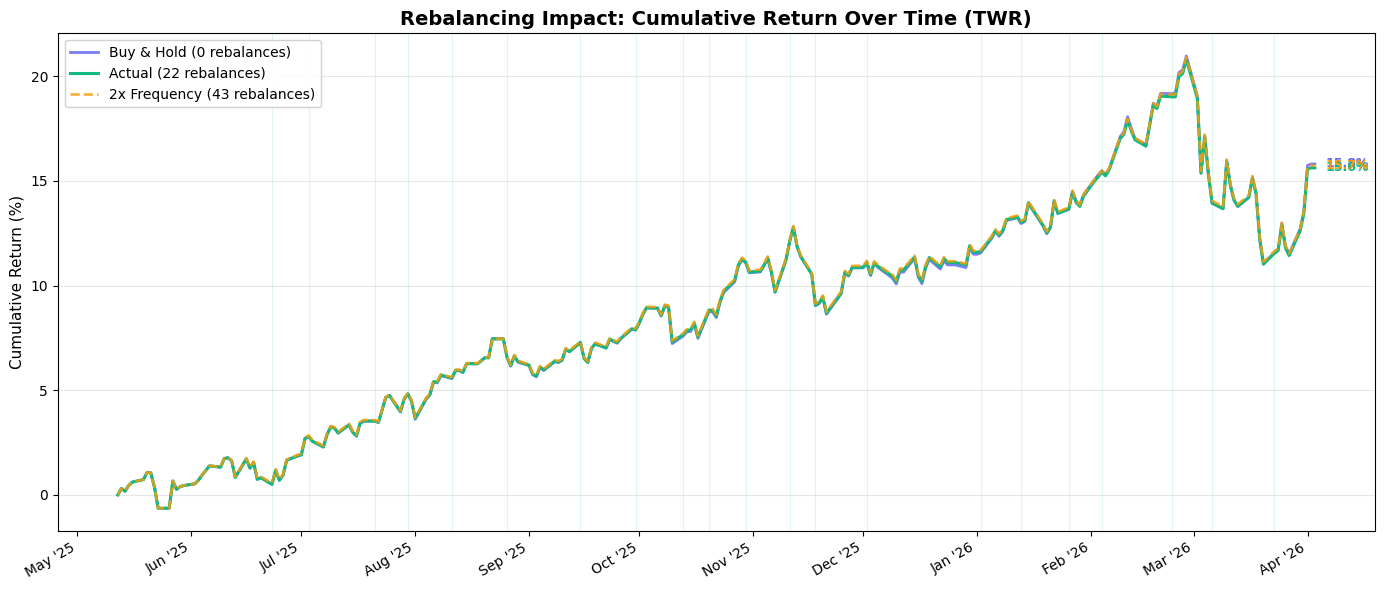


Final Cumulative Returns (TWR):
  Buy & Hold:                     15.81%
  Actual (22 rebalances):    15.62%
  2x Frequency (43 rebal): 15.73%


In [6]:
sorted_rebal = sorted(rebalance_dates)
double_rebal_dates = []
for i in range(len(sorted_rebal)):
    double_rebal_dates.append(sorted_rebal[i])
    if i < len(sorted_rebal) - 1:
        mid = sorted_rebal[i] + (sorted_rebal[i + 1] - sorted_rebal[i]) / 2
        double_rebal_dates.append(mid + pd.tseries.offsets.BDay(0))
double_rebal_dates = sorted(set(double_rebal_dates))

target_weights = {tkr: cost / bnh_cost for tkr, cost in bnh_ticker_cost.items()}
double_twr_series = bt.run_simulated_rebalance(
    bnh_holdings, target_weights, double_rebal_dates
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt.all_dates, bnh_series, label="Buy & Hold (0 rebalances)",
        color="#6366f1", linewidth=2, alpha=0.85)
ax.plot(bt.all_dates, actual_twr_series,
        label=f"Actual ({len(sorted_rebal)} rebalances)",
        color="#10b981", linewidth=2.2)
ax.plot(bt.all_dates, double_twr_series,
        label=f"2x Frequency ({len(double_rebal_dates)} rebalances)",
        color="#f59e0b", linewidth=1.8, linestyle="--", alpha=0.85)

for rd in sorted_rebal[1:]:
    ax.axvline(rd, color="#10b981", alpha=0.12, linewidth=0.8)

ax.set_title("Rebalancing Impact: Cumulative Return Over Time (TWR)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

for label, series, color in [
    ("B&H", bnh_series, "#6366f1"),
    ("Actual", actual_twr_series, "#10b981"),
    ("2x", double_twr_series, "#f59e0b"),
]:
    ax.annotate(f"{series.iloc[-1]:.1f}%", xy=(bt.all_dates[-1], series.iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center")

plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR):")
print(f"  Buy & Hold:                     {bnh_series.iloc[-1]:.2f}%")
print(f"  Actual ({len(sorted_rebal)} rebalances):    {actual_twr_series.iloc[-1]:.2f}%")
print(f"  2x Frequency ({len(double_rebal_dates)} rebal): {double_twr_series.iloc[-1]:.2f}%")


### 1.3.2 Rolling volatility

30-day annualised [volatility](../content/99_glossary.md#risk-metrics) across three
strategies: actual portfolio, buy-and-hold equivalent, and blended benchmark.
A strategy that achieves the same end return at lower vol delivered a better
risk-adjusted outcome for the investor sitting through the drawdowns.

RISK & VOLATILITY SUMMARY (30-Day Rolling Window)


,Strategy,Avg Vol (%),Max 30d Vol (%)
0,Buy & Hold,8.57,18.47
1,Actual (22 rebalances),8.45,18.02
2,2x Frequency (43 rebalances),8.42,18.04


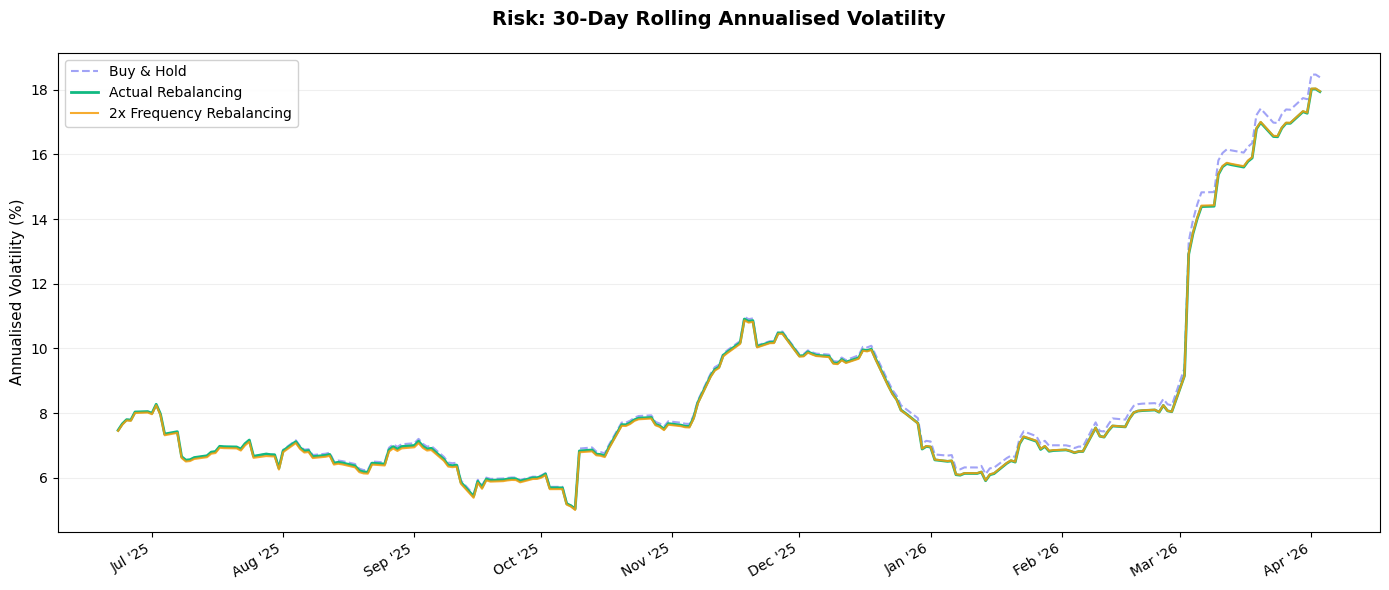

In [7]:
vol_actual = rolling_volatility_from_cumret(actual_twr_series, window=30)
vol_bnh    = rolling_volatility_from_cumret(bnh_series, window=30)
vol_2x     = rolling_volatility_from_cumret(double_twr_series, window=30)

vol_summary = pd.DataFrame({
    "Strategy": [
        "Buy & Hold",
        f"Actual ({len(sorted_rebal)} rebalances)",
        f"2x Frequency ({len(double_rebal_dates)} rebalances)",
    ],
    "Avg Vol (%)": [vol_bnh.mean(), vol_actual.mean(), vol_2x.mean()],
    "Max 30d Vol (%)": [vol_bnh.max(), vol_actual.max(), vol_2x.max()],
}).round(2)
print("RISK & VOLATILITY SUMMARY (30-Day Rolling Window)")
display(vol_summary)

plt.figure(figsize=(14, 6))
plt.plot(bt.all_dates, vol_bnh, label="Buy & Hold", color="#6366f1",
         linestyle="--", alpha=0.6)
plt.plot(bt.all_dates, vol_actual, label="Actual Rebalancing",
         color="#10b981", linewidth=2)
plt.plot(bt.all_dates, vol_2x, label="2x Frequency Rebalancing",
         color="#f59e0b", linewidth=1.5, alpha=0.85)
plt.title("Risk: 30-Day Rolling Annualised Volatility",
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Annualised Volatility (%)", fontsize=11)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc="upper left", fontsize=10, framealpha=0.9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


### 1.3.3 Correlation dynamics (2025 portfolio)

As equity markets sell off, assets that looked uncorrelated in calm conditions
tend to become correlated — investors sell what they can, not what they want
to. The chart below tracks the **rolling 90-day average pairwise correlation**
across the 2025 portfolio. Spikes toward 1.0 mark the moments when traditional
diversification offered least protection.

The snapshots at regime-change dates (tariff shock, trade walkback,
SaaSpocalypse, Iran–US conflict peak) show whether the portfolio's
diversification held up or collapsed at each inflection point.

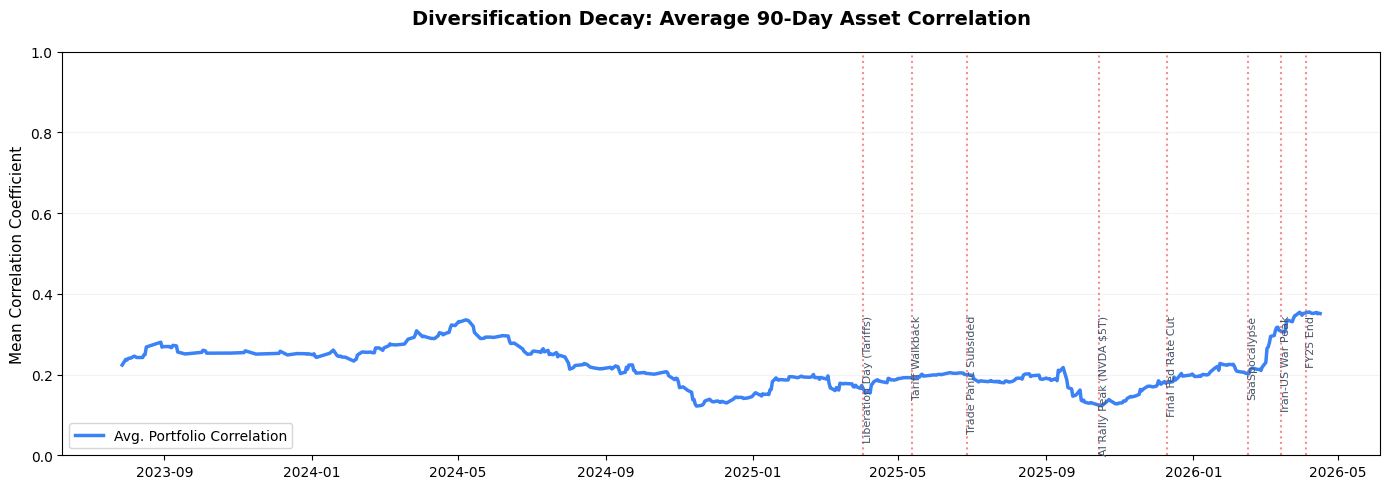

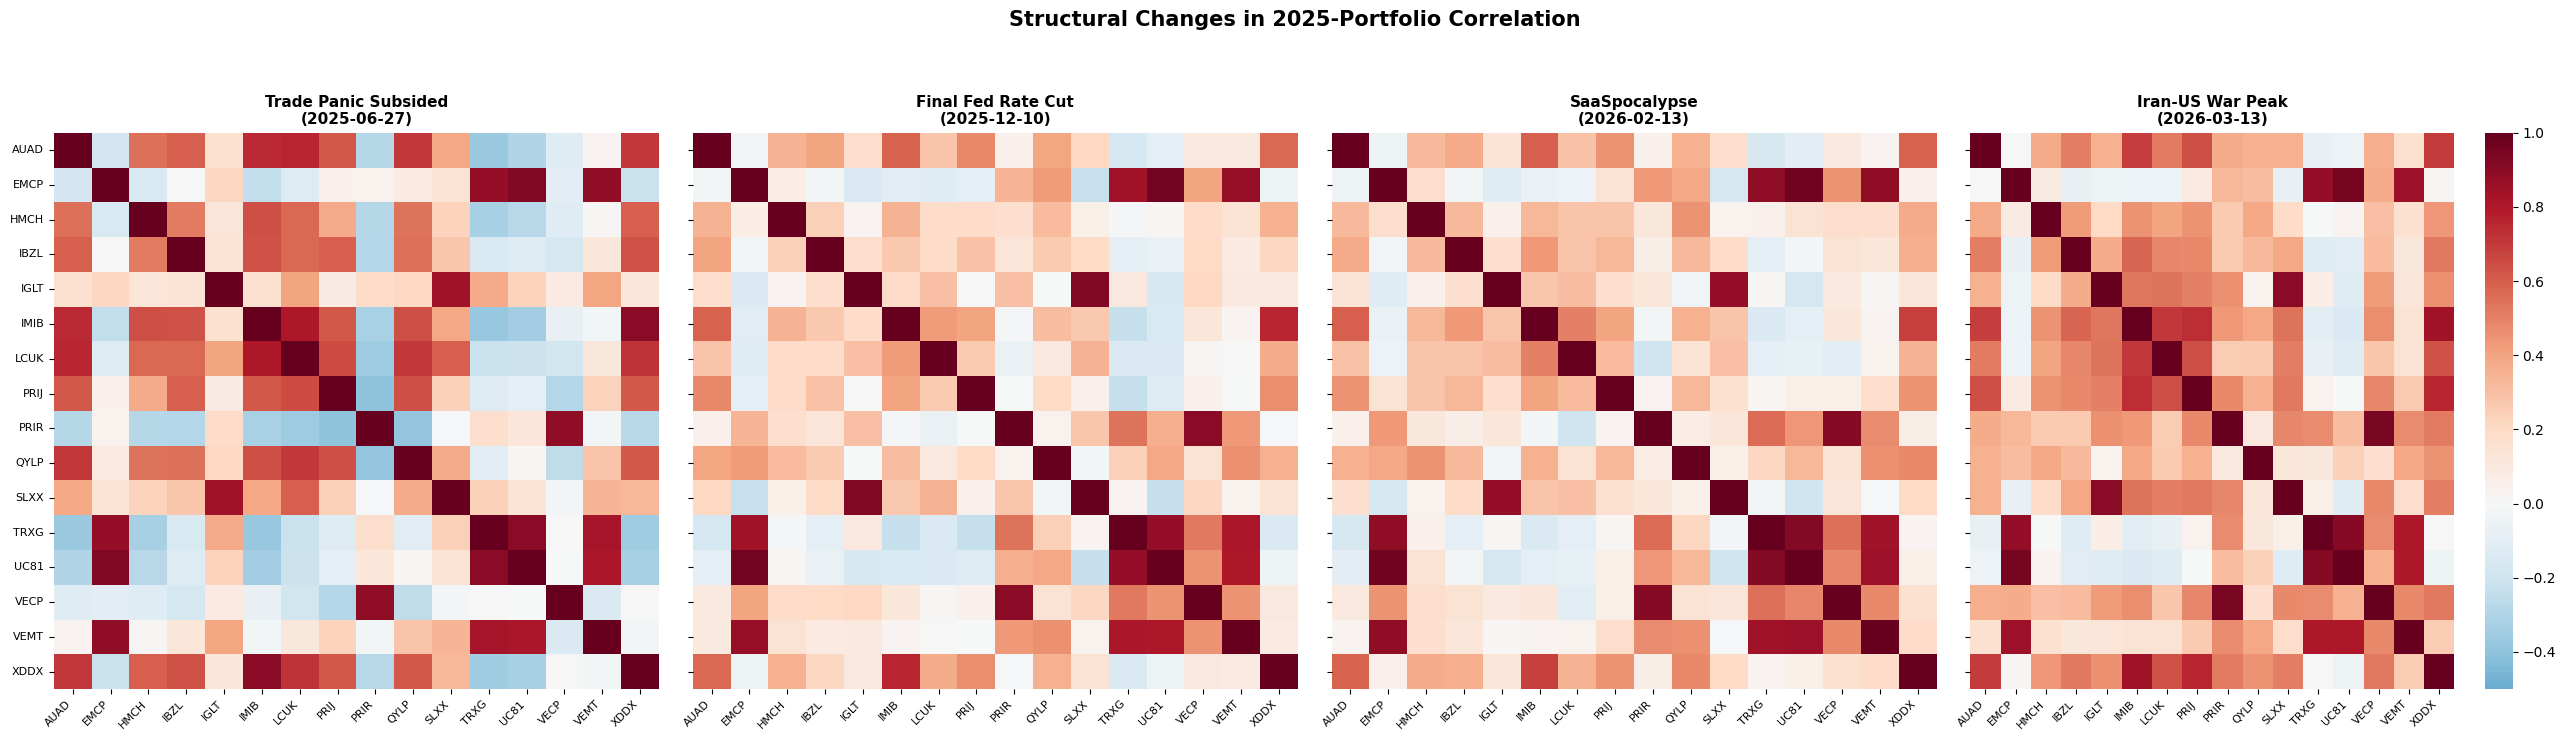


--- Average pairwise correlation at each regime snapshot ---
Event                                     Date    Avg Corr
----------------------------------------------------------
Trade Panic Subsided                2025-06-27       0.198
Final Fed Rate Cut                  2025-12-10       0.200
SaaSpocalypse                       2026-02-13       0.225
Iran-US War Peak                    2026-03-13       0.333


In [8]:
timeline = {
    'Liberation Day (Tariffs)': '2025-04-02',
    'Tariff Walkback': '2025-05-13',
    'Trade Panic Subsided': '2025-06-27',
    'AI Rally Peak (NVDA $5T)': '2025-10-15',
    'Final Fed Rate Cut': '2025-12-10',
    'SaaSpocalypse': '2026-02-15',
    'Iran-US War Peak': '2026-03-15',
    'FY25 End': str(FY25_END.date()),
}
snapshot_events = [
    'Trade Panic Subsided', 'Final Fed Rate Cut',
    'SaaSpocalypse', 'Iran-US War Peak',
]

returns_df_25 = bt.price_df[all_tickers].pct_change().dropna()
rolling_corr = returns_df_25.rolling(window=90).corr()

avg_corr_series = rolling_avg_pairwise_corr(returns_df_25, window=90)

plt.figure(figsize=(14, 5))
plt.plot(avg_corr_series, color='#3b82f6', linewidth=2.5,
         label="Avg. Portfolio Correlation")
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_corr_series.dropna().index.min():
        plt.axvline(dt, color='#ef4444', linestyle=':', alpha=0.6)
        plt.text(dt, plt.ylim()[1] * 0.95, name, rotation=90,
                 verticalalignment='top', fontsize=8, color='#475569')
plt.title("Diversification Decay: Average 90-Day Asset Correlation",
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Mean Correlation Coefficient", fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.15)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Snapshot heatmaps at regime-shift dates
fig, axes = plt.subplots(1, len(snapshot_events), figsize=(26, 7))
available_dates = rolling_corr.index.get_level_values(0).unique()
for i, event_name in enumerate(snapshot_events):
    target = pd.to_datetime(timeline[event_name])
    eligible = available_dates[available_dates <= target]
    if len(eligible) == 0:
        axes[i].set_visible(False)
        continue
    nearest = eligible[-1]
    sns.heatmap(rolling_corr.loc[nearest], annot=False, cmap='RdBu_r',
                center=0, vmin=-0.5, vmax=1, ax=axes[i],
                cbar=(i == len(snapshot_events) - 1))
    axes[i].set_title(f"{event_name}\n({nearest.strftime('%Y-%m-%d')})",
                      fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45,
                             ha='right', fontsize=8)
    if i > 0:
        axes[i].set_yticklabels([])
    else:
        axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=8)
plt.suptitle("Structural Changes in 2025-Portfolio Correlation",
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ── Compact correlation summary table (readable at print size) ──────────────
print("\n--- Average pairwise correlation at each regime snapshot ---")
print(f"{'Event':<32}  {'Date':>12}  {'Avg Corr':>10}")
print("-" * 58)
for event_name in snapshot_events:
    target = pd.to_datetime(timeline[event_name])
    eligible = available_dates[available_dates <= target]
    if len(eligible) == 0:
        continue
    nearest = eligible[-1]
    corr_mat = rolling_corr.loc[nearest]
    mask = np.triu(np.ones(corr_mat.shape), k=1).astype(bool)
    avg = float(corr_mat.where(mask).stack().mean())
    print(f"{event_name:<32}  {nearest.strftime('%Y-%m-%d'):>12}  {avg:>10.3f}")

### 1.4 Professional metrics vs blended benchmark

The actual [TWR](../content/99_glossary.md#return-metrics) is compared against a
**fixed-weight blended benchmark** built from the Day 1 target weights, held
without rebalancing. This is the "what if I had bought the basket and never
touched it?" baseline — the most honest comparison for a rebalancing strategy.

[TER](../content/99_glossary.md#costs) is **not** subtracted: adjusted-close prices
already embed it through the NAV mechanism (see
[Methodology](../content/00b_methodology.md#ter-ocf-and-adjusted-close-prices)).

In [ ]:
total_dep = sum(initial_deposits.values()) if initial_deposits else 0
bench_weights = (
    {t: v / total_dep for t, v in initial_deposits.items()}
    if total_dep > 0 else {}
)

# Per-ticker TER (bps) for disclosure only — already embedded in prices.
ter_bps = {}
try:
    p25 = load_portfolio(year=2025)
    for _, r in p25.iterrows():
        ter_pct = float(r.get("ter", 0) or 0)
        ter_bps[r["ticker"]] = ter_pct * 100
except Exception as exc:
    print(f"TER lookup failed ({exc}); weighted-average TER will be 0.")

weighted_avg_ter_bps = sum(
    bench_weights.get(t, 0) * ter_bps.get(t, 0) for t in bench_weights
)

blended_bench = bt.build_blended_benchmark_no_rebalance(bench_weights)

aligned = pd.concat(
    [actual_twr_series.rename("portfolio"), blended_bench.rename("benchmark")],
    axis=1, join="inner",
).dropna()

port_daily = (1 + aligned["portfolio"] / 100).pct_change().dropna()
bench_daily = (1 + aligned["benchmark"] / 100).pct_change().dropna()

ann_ret_port = (1 + port_daily.mean()) ** 252 - 1
ann_vol_port = float(port_daily.std() * np.sqrt(252))
sharpe_port = calculate_sharpe_ratio(ann_ret_port, ann_vol_port)
ann_ret_bench = (1 + bench_daily.mean()) ** 252 - 1
ann_vol_bench = float(bench_daily.std() * np.sqrt(252))
sharpe_bench = calculate_sharpe_ratio(ann_ret_bench, ann_vol_bench)

mdd_port = calculate_max_drawdown(1 + aligned["portfolio"] / 100)
mdd_bench = calculate_max_drawdown(1 + aligned["benchmark"] / 100)
beta = calculate_beta(port_daily, bench_daily)
te = calculate_tracking_error(port_daily, bench_daily)
ir = calculate_information_ratio(port_daily, bench_daily)

def _fmt_pct(x): return f"{x*100:+.2f}%" if pd.notna(x) else "—"
def _fmt_num(x, nd=2): return f"{x:.{nd}f}" if pd.notna(x) else "—"

print("=" * 78)
print("  Professional Metrics — 2025 Portfolio vs Day-1 Blended Benchmark")
print("=" * 78)
print(f"  Risk-free rate (config):          {RISK_FREE_RATE:.2%}")
print(f"  Weighted-avg TER (disclosure):    {weighted_avg_ter_bps:.1f} bps  "
      f"(already embedded in prices)")
print("-" * 78)
print(f"  {'':30s}  {'Portfolio':>14s}   {'Benchmark':>14s}")
print(f"  {'TWR final (net of TER)':30s}  "
      f"{_fmt_num(actual_twr_series.iloc[-1]):>13s}%  "
      f"{_fmt_num(blended_bench.iloc[-1]):>13s}%")
print(f"  {'Annualised return':30s}  {_fmt_pct(ann_ret_port):>14s}   "
      f"{_fmt_pct(ann_ret_bench):>14s}")
print(f"  {'Annualised volatility':30s}  {_fmt_pct(ann_vol_port):>14s}   "
      f"{_fmt_pct(ann_vol_bench):>14s}")
print(f"  {'Sharpe ratio':30s}  {_fmt_num(sharpe_port):>14s}   "
      f"{_fmt_num(sharpe_bench):>14s}")
print(f"  {'Max drawdown':30s}  {_fmt_pct(mdd_port['value']):>14s}   "
      f"{_fmt_pct(mdd_bench['value']):>14s}")
print(f"  {'   peak → trough':30s}  "
      f"{mdd_port['peak_date'].date()} → {mdd_port['trough_date'].date()}")
print(f"  {'Beta (port vs blended)':30s}  {_fmt_num(beta):>14s}")
print(f"  {'Tracking error (annualised)':30s}  {_fmt_pct(te):>14s}")
print(f"  {'Information Ratio':30s}  {_fmt_num(ir):>14s}")
print("=" * 78)


### 1.5 Holdings at FY25 end (4 Apr 2026)

Share ledger snapshot valued at FY25 closing prices, with cost basis and
per-ticker [MWR](../content/99_glossary.md#future-metrics-not-yet-in-the-book). This
is the authoritative position statement for the end of the 2025-26 tax year.

In [10]:
holdings_rows = []
for t in sorted(share_ledger.keys()):
    shares = share_ledger[t]
    if shares <= 0:
        continue
    px = bt.get_price(t, FY25_END) or 0
    val = round(shares * px, 2)
    cost = cost_basis[t]
    mwr = ((val / cost) - 1) * 100 if cost > 0 else 0
    holdings_rows.append({
        "Ticker": t,
        "Shares": round(shares, 4),
        "Price (£)": round(px, 2),
        "Value (£)": val,
        "Cost (£)": round(cost, 2),
        "P&L (£)": round(val - cost, 2),
        "MWR (%)": round(mwr, 2),
    })
holdings_df = pd.DataFrame(holdings_rows)
display(holdings_df)
print(f"Total Value: £{holdings_df['Value (£)'].sum():,.2f}")
print(f"Total Cost:  £{holdings_df['Cost (£)'].sum():,.2f}")
print(f"Total P&L:   £{holdings_df['P&L (£)'].sum():,.2f}")


,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
0,AUAD,176.1577,20.62,3632.81,3232.01,400.80,12.40
1,EMCP,3.3979,67.32,228.75,231.21,-2.46,-1.06
2,HMCH,78.7293,5.79,455.84,449.23,6.61,1.47
3,IBZL,81.4062,23.48,1911.82,1290.55,621.27,48.14
4,IGLT,22.9242,9.82,225.12,228.64,-3.52,-1.54
5,IMIB,175.9615,24.14,4248.59,3592.78,655.81,18.25
6,LCUK,144.6143,14.55,2104.14,1756.15,347.99,19.82
7,PRIJ,55.8769,29.02,1621.69,1332.76,288.93,21.68
8,PRIR,46.2379,14.70,679.88,673.30,6.58,0.98
9,QYLP,130.1067,12.17,1583.23,1552.99,30.24,1.95


Total Value: £23,091.61
Total Cost:  £20,760.29
Total P&L:   £2,331.32


## 2. Counterfactual: would the 2026 portfolio have been better?

The 2025 portfolio held only equities and bonds. Adding **precious metals
(5%)** and **broad commodities (10%)** in 2026 was motivated by two hypotheses:

1. **Lower correlation during equity drawdowns** — gold and commodity ETCs
   tend to zig when equities zag, providing rebalancing dry powder exactly
   when it is most valuable.
2. **Inflation and tail-risk hedge** — commodities provide some protection
   against inflationary regimes; gold provides protection against systemic
   stress.

This section tests both hypotheses *retrospectively* on FY25 data, answering:
does the 2026 allocation look better on a risk-adjusted basis when measured
over the completed year?

### 2.1 Correlation dynamics (2026 portfolio, FY25 window)

The same rolling-correlation analysis as section 1.3.3, but applied to the
full 2026 roster. The new tickers (precious metals + commodity ETCs) should
exhibit **lower correlation with the equity block** during stress events —
that is the portfolio-construction thesis being tested.

2026 portfolio tickers (20): ['AIGA', 'AIGE', 'COPA', 'EMCP', 'HKOR', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'ISJP', 'IUKD', 'PRIR', 'RMAP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VGER', 'WSIL', 'XSTC']


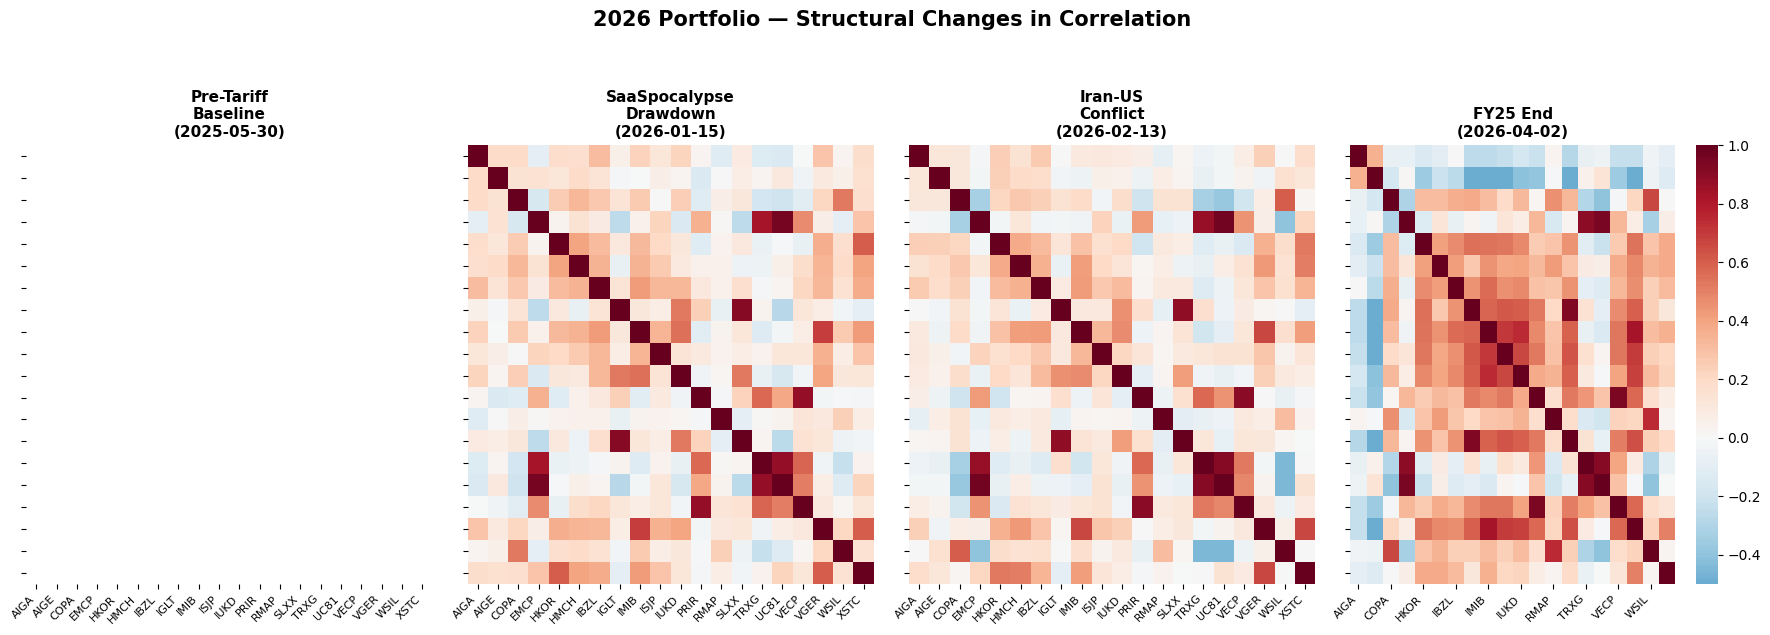


Key insight: during equity-stress windows, metals/commodities (SPLT,
SSLN, COMG, CXAP) exhibit low or negative correlation with the equity
block — providing rebalancing dry powder.


In [11]:
portfolio_26 = load_portfolio(year=2026)
tickers_26 = sorted(portfolio_26['ticker'].unique().tolist())
print(f"2026 portfolio tickers ({len(tickers_26)}): {tickers_26}")

price_data_26 = {}
for t in tickers_26:
    try:
        price_data_26[t] = provider.get_historical_prices(t)
    except Exception as exc:
        print(f"  Warning: {t}: {exc}")

close_df_26 = pd.DataFrame(
    {t: df['close'] for t, df in price_data_26.items() if 'close' in df.columns}
).dropna(axis=1, how='all').loc[FY25_START:FY25_END].dropna()

daily_ret_26 = close_df_26.pct_change().dropna()
rolling_corr_26 = daily_ret_26.rolling(window=90).corr()
available_26 = rolling_corr_26.index.get_level_values(0).unique()

snap26 = {
    'Pre-Tariff\nBaseline':  '2025-06-01',
    'SaaSpocalypse\nDrawdown': '2026-01-15',
    'Iran-US\nConflict':       '2026-02-15',
    'FY25 End':                str(FY25_END.date()),
}

fig, axes = plt.subplots(1, len(snap26), figsize=(18, 6), sharey=True)
for i, (name, date_str) in enumerate(snap26.items()):
    target = pd.to_datetime(date_str)
    eligible = available_26[available_26 <= target]
    if len(eligible) == 0:
        axes[i].set_visible(False)
        continue
    nearest = eligible[-1]
    sns.heatmap(rolling_corr_26.loc[nearest], annot=False, cmap='RdBu_r',
                center=0, vmin=-0.5, vmax=1, ax=axes[i],
                cbar=(i == len(snap26) - 1))
    axes[i].set_title(f"{name}\n({nearest.strftime('%Y-%m-%d')})",
                      fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45,
                             ha='right', fontsize=8)
    if i > 0:
        axes[i].set_yticklabels([])
    else:
        axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=8)
plt.suptitle('2026 Portfolio — Structural Changes in Correlation',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
print("\nKey insight: during equity-stress windows, metals/commodities (SPLT,")
print("SSLN, COMG, CXAP) exhibit low or negative correlation with the equity")
print("block — providing rebalancing dry powder.")

### 2.2 Rebalancing frequency counterfactual (2026 weights)

If the 2026 portfolio had been running during FY25, how often would you have
needed to rebalance to capture the diversification benefit? Three scenarios
over the same FY25 window:

| Strategy | Trades | Effort |
|---|---|---|
| **Buy & Hold** | 1 (day one only) | Minimum |
| **Monthly** | ~22 rebalances | One afternoon per month |
| **Bi-weekly** | ~44 rebalances | Every two weeks |

A higher-frequency strategy only justifies its effort if it meaningfully
improves the risk-adjusted return — which the comparison will reveal.

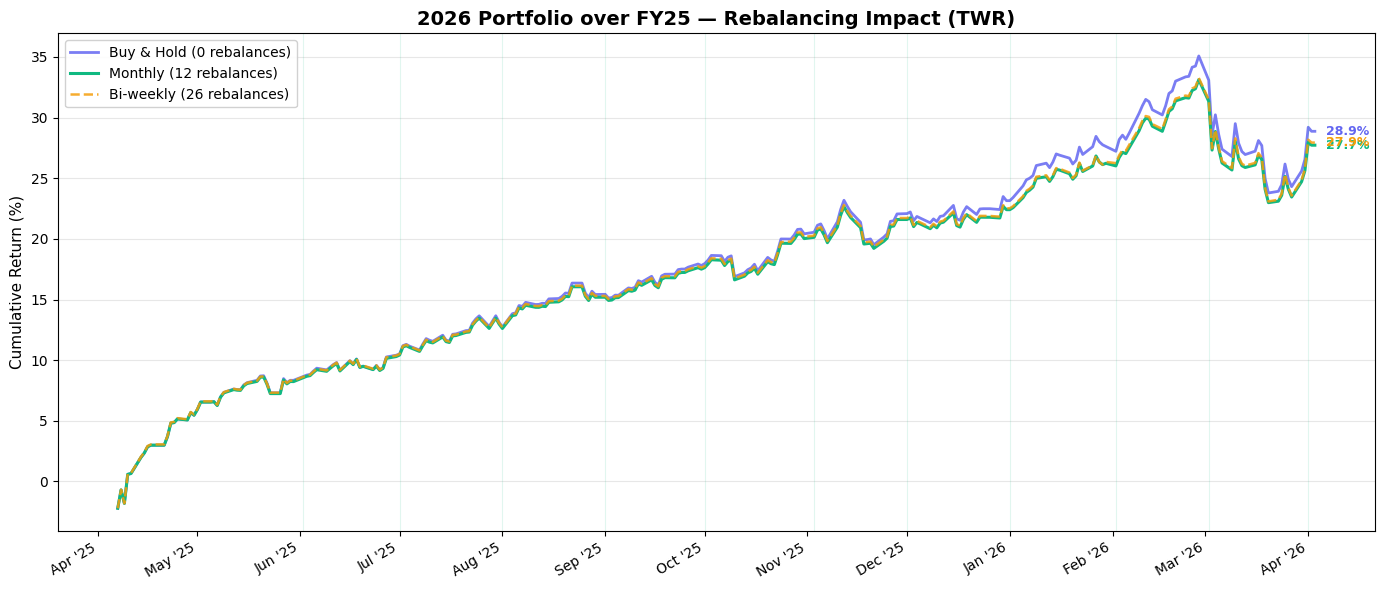


Final Cumulative Returns (TWR) — 2026 Portfolio over FY25:
  Buy & Hold:                       28.87%
  Monthly (12 rebalances):     27.72%
  Bi-weekly (26 rebalances):   27.94%


In [12]:
bt26 = Backtester(price_data_26, FY25_START, FY25_END)

weight_map = dict(zip(portfolio_26['ticker'], portfolio_26['final_cash_weights']))
total_w = sum(weight_map.values())
target_weights_26 = {
    t: w / total_w for t, w in weight_map.items() if t in price_data_26
}

initial_capital = 20_000.0
bnh_holdings_26 = {}
bnh_cost_26 = 0.0
for tkr, w in target_weights_26.items():
    alloc = initial_capital * w
    px = bt26.get_price(tkr, FY25_START)
    if px and px > 0:
        bnh_holdings_26[tkr] = alloc / px
        bnh_cost_26 += alloc

bnh_twr_26 = bt26.run_buy_and_hold_series(bnh_holdings_26)

monthly_dates = pd.bdate_range(FY25_START, FY25_END, freq='BMS').tolist()
if monthly_dates and monthly_dates[0] < FY25_START:
    monthly_dates[0] = FY25_START
monthly_twr_26 = bt26.run_simulated_rebalance(
    bnh_holdings_26, target_weights_26, monthly_dates
)

biweekly_dates = pd.bdate_range(FY25_START, FY25_END, freq='10B').tolist()
if biweekly_dates and biweekly_dates[0] < FY25_START:
    biweekly_dates[0] = FY25_START
biweekly_twr_26 = bt26.run_simulated_rebalance(
    bnh_holdings_26, target_weights_26, biweekly_dates
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt26.all_dates, bnh_twr_26, label='Buy & Hold (0 rebalances)',
        color='#6366f1', linewidth=2, alpha=0.85)
ax.plot(bt26.all_dates, monthly_twr_26,
        label=f'Monthly ({len(monthly_dates)} rebalances)',
        color='#10b981', linewidth=2.2)
ax.plot(bt26.all_dates, biweekly_twr_26,
        label=f'Bi-weekly ({len(biweekly_dates)} rebalances)',
        color='#f59e0b', linewidth=1.8, linestyle='--', alpha=0.85)
for rd in monthly_dates[1:]:
    ax.axvline(rd, color='#10b981', alpha=0.12, linewidth=0.8)
ax.set_title('2026 Portfolio over FY25 — Rebalancing Impact (TWR)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)
for label, series, color in [
    ('B&H', bnh_twr_26, '#6366f1'),
    ('Monthly', monthly_twr_26, '#10b981'),
    ('Bi-wkly', biweekly_twr_26, '#f59e0b'),
]:
    if series is not None and len(series) > 0:
        ax.annotate(f'{series.iloc[-1]:.1f}%',
                    xy=(bt26.all_dates[-1], series.iloc[-1]),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=color, va='center')
plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR) — 2026 Portfolio over FY25:")
print(f"  Buy & Hold:                       {bnh_twr_26.iloc[-1]:.2f}%")
print(f"  Monthly ({len(monthly_dates)} rebalances):     "
      f"{monthly_twr_26.iloc[-1]:.2f}%")
print(f"  Bi-weekly ({len(biweekly_dates)} rebalances):   "
      f"{biweekly_twr_26.iloc[-1]:.2f}%")


### 2.3 Side-by-side: 2025 vs 2026 portfolios over FY25

Both portfolios evaluated over the **same FY25 window** using their
respective target weights, with dynamic weight renormalisation for any 2026
ticker whose price history starts mid-window.

This directly answers: *would the four-class allocation have delivered a
materially different investor experience last year?*

In [13]:
raw_w25 = dict(zip(portfolio_25['ticker'], portfolio_25['final_cash_weights']))
raw_w26 = dict(zip(portfolio_26['ticker'], portfolio_26['final_cash_weights']))

union_tickers = sorted(set(list(raw_w25) + list(raw_w26)))
union_prices = {}
for t in union_tickers:
    try:
        union_prices[t] = provider.get_historical_prices(t)
    except Exception as exc:
        print(f"  Warning: {t}: {exc}")

close_union = pd.DataFrame(
    {t: df['close'] for t, df in union_prices.items() if 'close' in df.columns}
).dropna(axis=1, how='all').loc[FY25_START:FY25_END]

available = set(close_union.columns)
raw_w25 = {t: w for t, w in raw_w25.items() if t in available}
raw_w26 = {t: w for t, w in raw_w26.items() if t in available}

daily_ret = close_union.pct_change()

port_ret_25 = dynamic_portfolio_return(daily_ret, raw_w25)
port_ret_26 = dynamic_portfolio_return(daily_ret, raw_w26)

s25 = sum(raw_w25.values()); weights_25 = {t: w / s25 for t, w in raw_w25.items()}
s26 = sum(raw_w26.values()); weights_26 = {t: w / s26 for t, w in raw_w26.items()}

cum_ret_25 = (1 + port_ret_25).cumprod() - 1
cum_ret_26 = (1 + port_ret_26).cumprod() - 1

WINDOW = 30  # shared rolling window for downstream cells

print(f"2025 portfolio: {len(raw_w25)} tickers — {sorted(raw_w25.keys())}")
print(f"2026 portfolio: {len(raw_w26)} tickers — {sorted(raw_w26.keys())}")
print(f"Window: {close_union.index.min().date()} → "
      f"{close_union.index.max().date()}  ({len(close_union)} trading days)")
for t in sorted(raw_w26):
    first_valid = close_union[t].first_valid_index()
    if first_valid and first_valid > FY25_START + pd.Timedelta(days=5):
        print(f"  {t}: data starts {first_valid.date()} "
              f"(dynamically excluded before this date)")


2025 portfolio: 16 tickers — ['AUAD', 'EMCP', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'LCUK', 'PRIJ', 'PRIR', 'QYLP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VEMT', 'XDDX']
2026 portfolio: 20 tickers — ['AIGA', 'AIGE', 'COPA', 'EMCP', 'HKOR', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'ISJP', 'IUKD', 'PRIR', 'RMAP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VGER', 'WSIL', 'XSTC']
Window: 2025-04-07 → 2026-04-02  (251 trading days)


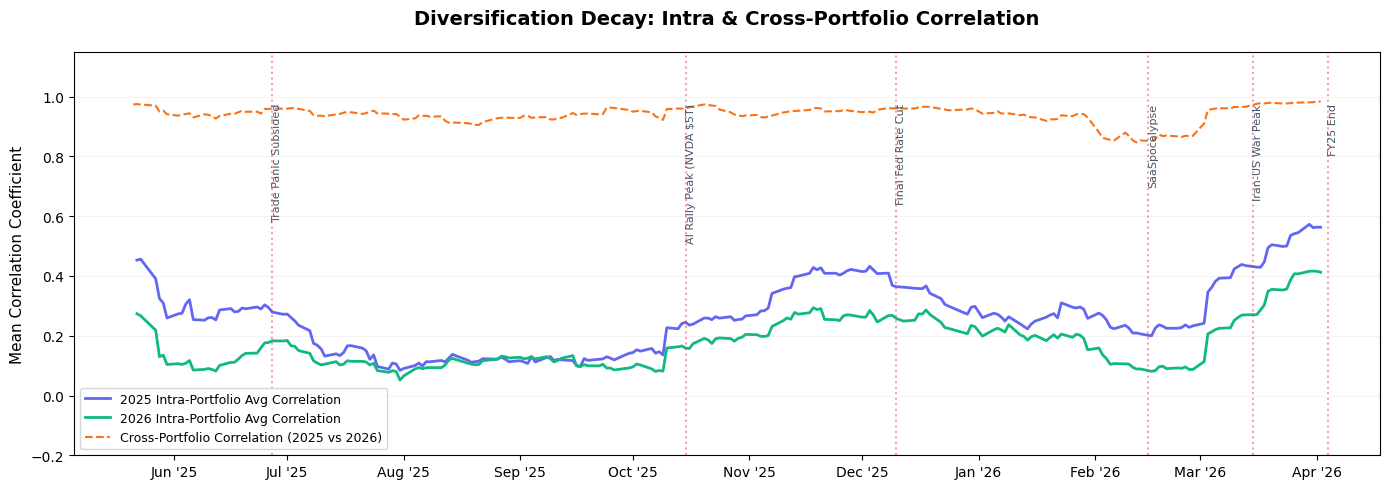

2025 intra — median: 0.259,  min: 0.084
2026 intra — median: 0.159,  min: 0.052
Cross      — median: 0.944


In [14]:
avg_corr_25 = rolling_avg_pairwise_corr(daily_ret[list(weights_25.keys())], WINDOW)
avg_corr_26 = rolling_avg_pairwise_corr(daily_ret[list(weights_26.keys())], WINDOW)
cross_corr  = port_ret_25.rolling(WINDOW).corr(port_ret_26)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_corr_25.index, avg_corr_25, color='#6366f1', linewidth=2,
        label='2025 Intra-Portfolio Avg Correlation')
ax.plot(avg_corr_26.index, avg_corr_26, color='#10b981', linewidth=2,
        label='2026 Intra-Portfolio Avg Correlation')
ax.plot(cross_corr.index, cross_corr, color='#f97316', linewidth=1.5,
        linestyle='--', label='Cross-Portfolio Correlation (2025 vs 2026)')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_corr_25.dropna().index.min():
        ax.axvline(dt, color='#ef4444', linestyle=':', alpha=0.5)
        ax.text(dt, ax.get_ylim()[1] * 0.95, name, rotation=90,
                verticalalignment='top', fontsize=8, color='#475569')
ax.set_title('Diversification Decay: Intra & Cross-Portfolio Correlation',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Mean Correlation Coefficient', fontsize=11)
ax.set_ylim(-0.2, 1.15)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(axis='y', alpha=0.15)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"2025 intra — median: {avg_corr_25.median():.3f},  min: {avg_corr_25.min():.3f}")
print(f"2026 intra — median: {avg_corr_26.median():.3f},  min: {avg_corr_26.min():.3f}")
print(f"Cross      — median: {cross_corr.median():.3f}")


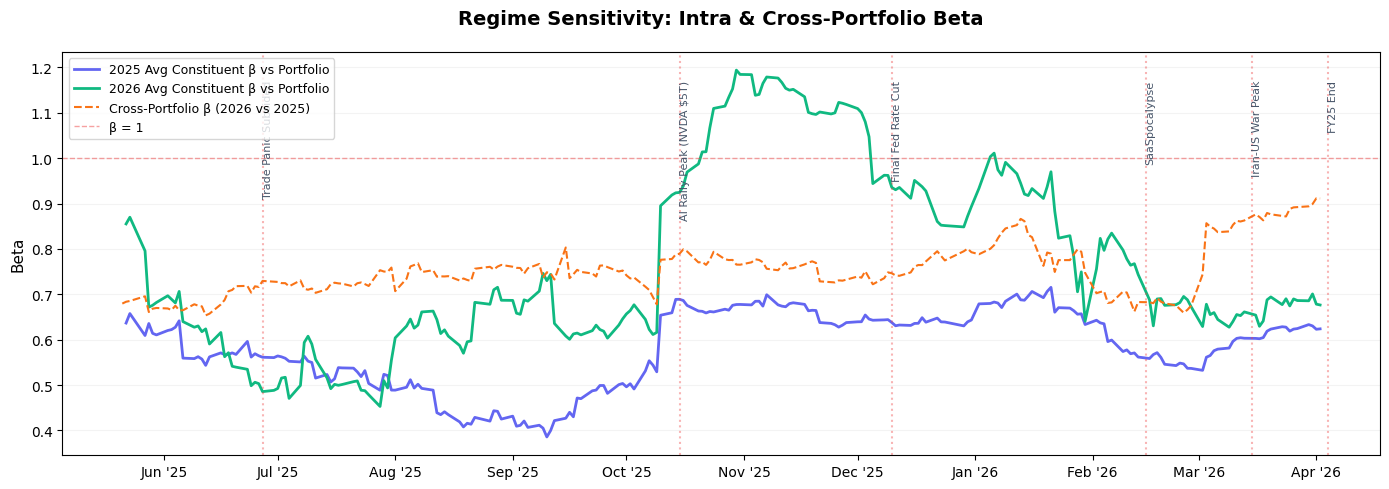

2025 avg constituent β — median: 0.596
2026 avg constituent β — median: 0.687
Cross-portfolio β     — median: 0.749


In [15]:
avg_beta_25 = rolling_constituent_beta(
    daily_ret[list(weights_25.keys())], port_ret_25, WINDOW
)
avg_beta_26 = rolling_constituent_beta(
    daily_ret[list(weights_26.keys())], port_ret_26, WINDOW
)
cross_cov  = port_ret_26.rolling(WINDOW).cov(port_ret_25)
cross_var  = port_ret_25.rolling(WINDOW).var()
cross_beta = (cross_cov / cross_var).clip(-3, 3)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_beta_25.index, avg_beta_25, color='#6366f1', linewidth=2,
        label='2025 Avg Constituent β vs Portfolio')
ax.plot(avg_beta_26.index, avg_beta_26, color='#10b981', linewidth=2,
        label='2026 Avg Constituent β vs Portfolio')
ax.plot(cross_beta.index, cross_beta, color='#f97316', linewidth=1.5,
        linestyle='--', label='Cross-Portfolio β (2026 vs 2025)')
ax.axhline(1.0, color='#ef4444', linestyle='--', alpha=0.5, linewidth=1,
           label='β = 1')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_beta_25.dropna().index.min():
        ax.axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
        ax.text(dt, ax.get_ylim()[1] * 0.95, name, rotation=90,
                verticalalignment='top', fontsize=8, color='#475569')
ax.set_title('Regime Sensitivity: Intra & Cross-Portfolio Beta',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Beta', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(axis='y', alpha=0.15)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"2025 avg constituent β — median: {avg_beta_25.median():.3f}")
print(f"2026 avg constituent β — median: {avg_beta_26.median():.3f}")
print(f"Cross-portfolio β     — median: {cross_beta.median():.3f}")


In [16]:
period_df = period_metrics_table(
    port_ret_25, port_ret_26, timeline,
    label_a='2025', label_b='2026',
)

def _colour_neg(val):
    if val is None or (isinstance(val, float) and val != val):
        return ''
    return 'color: #dc2626; font-weight: bold' if val < 0 else ''

def _colour_excess(val):
    colour = '#16a34a' if val > 0 else '#dc2626' if val < 0 else '#000'
    return f'color: {colour}; font-weight: bold'

styled = (period_df.style
    .format({
        'Days': '{:.0f}',
        'Return 2025 (%)': '{:+.2f}',
        'Return 2026 (%)': '{:+.2f}',
        'Excess (%)': '{:+.2f}',
        'Vol 2025 (ann.)': '{:.2f}',
        'Vol 2026 (ann.)': '{:.2f}',
        'Correlation': '{:.3f}',
        'Beta': '{:.3f}',
    })
    .map(_colour_neg, subset=['Return 2025 (%)', 'Return 2026 (%)', 'Beta'])
    .map(_colour_excess, subset=['Excess (%)'])
    .set_caption('Period-by-Period Regime Metrics: 2025 vs 2026 Portfolio'))
styled

,Days,Return 2025 (%),Return 2026 (%),Excess (%),Vol 2025 (ann.),Vol 2026 (ann.),Correlation,Beta
Period,,,,,,,,
Liberation Day (Tariffs) → Tariff Walkback,24,+13.75,+9.96,-3.79,15.93,11.17,0.974,0.683
Tariff Walkback → Trade Panic Subsided,33,+1.65,+2.39,+0.74,8.09,6.15,0.946,0.720
Trade Panic Subsided → AI Rally Peak (NVDA $5T),78,+6.84,+7.20,+0.36,6.85,5.62,0.947,0.777
AI Rally Peak (NVDA $5T) → Final Fed Rate Cut,41,+2.29,+3.27,+0.98,9.69,7.53,0.947,0.735
Final Fed Rate Cut → SaaSpocalypse,45,+6.21,+6.78,+0.57,7.86,6.55,0.892,0.743
SaaSpocalypse → Iran-US War Peak,20,-2.73,-2.64,+0.10,18.97,16.99,0.985,0.882
Iran-US War Peak → FY25 End,14,+1.72,+1.52,-0.20,16.60,16.05,0.978,0.945


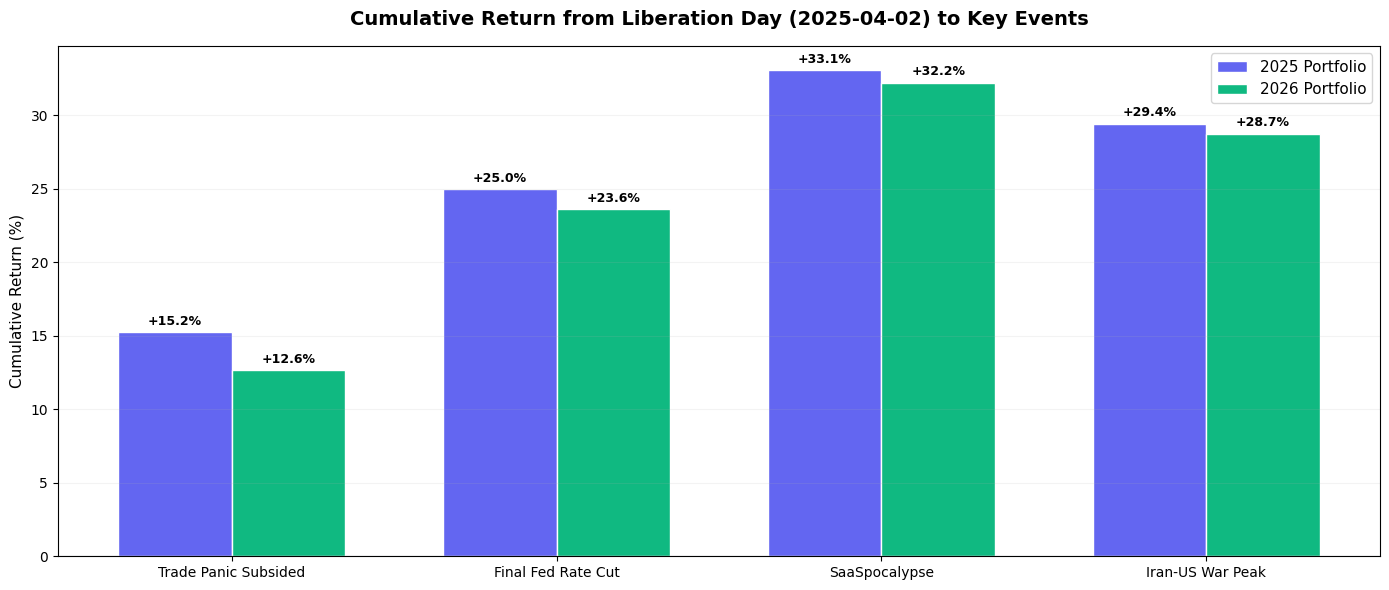

In [17]:
base_date = pd.to_datetime(timeline['Liberation Day (Tariffs)'])
snap_labels, snap_25, snap_26 = [], [], []
for ev in snapshot_events:
    ev_date = pd.to_datetime(timeline[ev])
    r25 = port_ret_25.loc[base_date:ev_date]
    r26 = port_ret_26.loc[base_date:ev_date]
    if len(r25) < 2:
        continue
    snap_labels.append(ev)
    snap_25.append(((1 + r25).cumprod().iloc[-1] - 1) * 100)
    snap_26.append(((1 + r26).cumprod().iloc[-1] - 1) * 100)

x = np.arange(len(snap_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
bars_25 = ax.bar(x - width / 2, snap_25, width, label='2025 Portfolio',
                 color='#6366f1', edgecolor='white')
bars_26 = ax.bar(x + width / 2, snap_26, width, label='2026 Portfolio',
                 color='#10b981', edgecolor='white')
for bars in [bars_25, bars_26]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + (0.3 if h >= 0 else -0.6),
                f'{h:+.1f}%', ha='center',
                va='bottom' if h >= 0 else 'top',
                fontsize=9, fontweight='bold')
ax.axhline(0, color='#94a3b8', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(snap_labels, fontsize=10)
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.set_title(f'Cumulative Return from Liberation Day '
             f'({base_date.date()}) to Key Events',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.15)
plt.tight_layout()
plt.show()


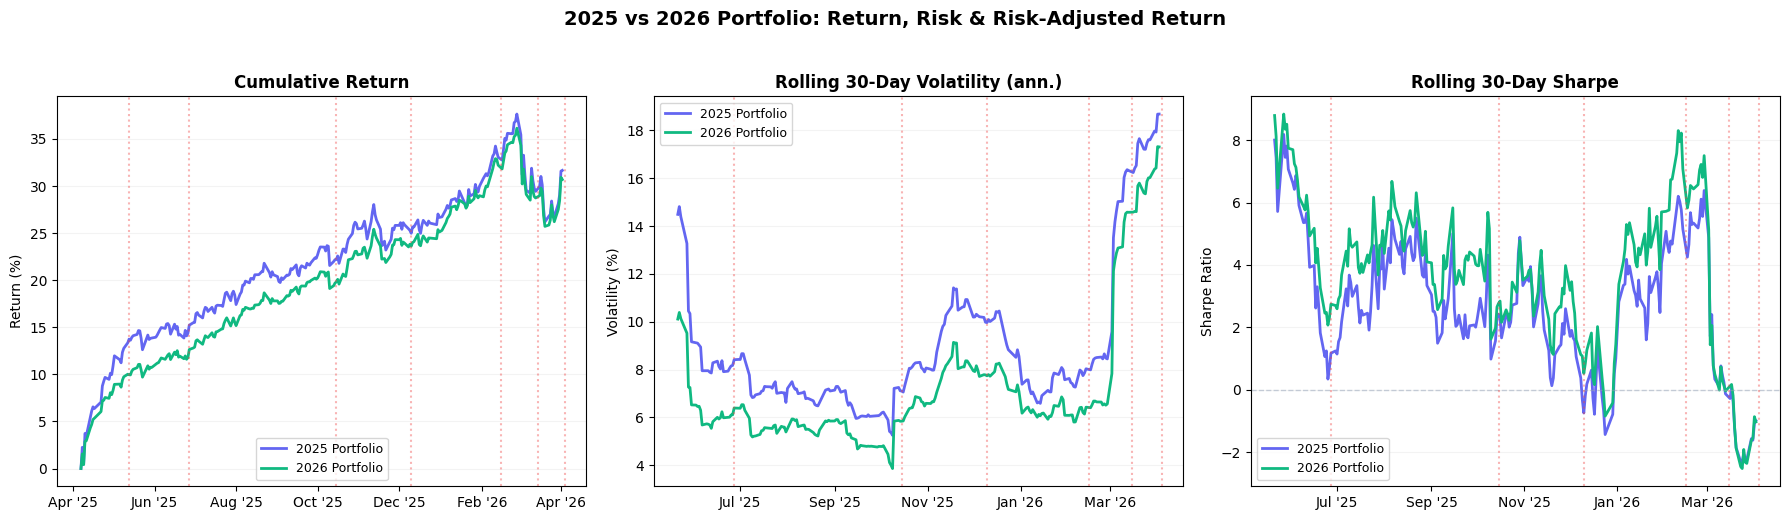

FY25 summary (2025-04-07 to 2026-04-02):
  2025 — Return: +31.67%   Vol: 10.92%   Sharpe: 2.912
  2026 — Return: +30.69%   Vol: 8.99%   Sharpe: 3.428


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cum_ret_25.index, cum_ret_25 * 100, color='#6366f1',
             linewidth=2, label='2025 Portfolio')
axes[0].plot(cum_ret_26.index, cum_ret_26 * 100, color='#10b981',
             linewidth=2, label='2026 Portfolio')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= cum_ret_25.index.min():
        axes[0].axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
axes[0].set_title('Cumulative Return', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.15)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

roll_vol_25 = port_ret_25.rolling(WINDOW).std() * np.sqrt(252) * 100
roll_vol_26 = port_ret_26.rolling(WINDOW).std() * np.sqrt(252) * 100
axes[1].plot(roll_vol_25.index, roll_vol_25, color='#6366f1', linewidth=2,
             label='2025 Portfolio')
axes[1].plot(roll_vol_26.index, roll_vol_26, color='#10b981', linewidth=2,
             label='2026 Portfolio')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= roll_vol_25.dropna().index.min():
        axes[1].axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
axes[1].set_title('Rolling 30-Day Volatility (ann.)', fontsize=12,
                  fontweight='bold')
axes[1].set_ylabel('Volatility (%)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.15)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

roll_sharpe_25 = rolling_sharpe(port_ret_25, window=WINDOW)
roll_sharpe_26 = rolling_sharpe(port_ret_26, window=WINDOW)
axes[2].plot(roll_sharpe_25.index, roll_sharpe_25, color='#6366f1', linewidth=2,
             label='2025 Portfolio')
axes[2].plot(roll_sharpe_26.index, roll_sharpe_26, color='#10b981', linewidth=2,
             label='2026 Portfolio')
axes[2].axhline(0, color='#94a3b8', linestyle='--', alpha=0.5, linewidth=1)
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= roll_sharpe_25.dropna().index.min():
        axes[2].axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
axes[2].set_title('Rolling 30-Day Sharpe', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sharpe Ratio', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.15)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.suptitle('2025 vs 2026 Portfolio: Return, Risk & Risk-Adjusted Return',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

ann_ret_25 = cum_ret_25.iloc[-1] / (len(cum_ret_25) / 252)
ann_ret_26 = cum_ret_26.iloc[-1] / (len(cum_ret_26) / 252)
ann_vol_25 = port_ret_25.std() * np.sqrt(252)
ann_vol_26 = port_ret_26.std() * np.sqrt(252)
sharpe_25  = ann_ret_25 / ann_vol_25 if ann_vol_25 > 0 else np.nan
sharpe_26  = ann_ret_26 / ann_vol_26 if ann_vol_26 > 0 else np.nan
print(f"FY25 summary ({close_union.index.min().date()} to "
      f"{close_union.index.max().date()}):")
print(f"  2025 — Return: {cum_ret_25.iloc[-1]*100:+.2f}%   "
      f"Vol: {ann_vol_25*100:.2f}%   Sharpe: {sharpe_25:.3f}")
print(f"  2026 — Return: {cum_ret_26.iloc[-1]*100:+.2f}%   "
      f"Vol: {ann_vol_26*100:.2f}%   Sharpe: {sharpe_26:.3f}")


## 3. Limitations of this analysis

This backtest is built for a DIY ISA investor. It is not audit-grade.
Items deliberately excluded:

- **Transaction costs beyond [TER](../content/99_glossary.md#costs)** — broker fees (zero
  on InvestEngine and Trading212 today), bid-ask spread, stamp duty (most
  ETFs exempt), and slippage. Fund TER is already in the price series.
- **Tracking difference vs the underlying index** — the rigorous fund
  efficiency measure that bundles TER, securities lending, sampling drag and
  tax withholding into one number. Listed under
  [future work](../content/00b_methodology.md#future-work).
- **Survivorship and left-censoring** — the JustETF universe is today's
  universe; closed or merged funds are absent. Each ETF's history starts at
  its own launch date.
- **Forward-looking claims** — every metric here is historical. Past
  [Sharpe](../content/99_glossary.md#risk-metrics),
  [beta](../content/99_glossary.md#risk-metrics) and
  [max drawdown](../content/99_glossary.md#risk-metrics) say nothing certain
  about what comes next.
- **FX decomposition** — unhedged-fund GBP returns include embedded currency
  exposure; it is not isolated as a separate factor.

## 4. Data quality check (2025 portfolio)

Price-history coverage for every 2025-portfolio ticker across the full FY25
window (5 Apr 2025 → 4 Apr 2026). Missing or stale data would silently
corrupt the [TWR](../content/99_glossary.md#return-metrics),
[Sharpe](../content/99_glossary.md#risk-metrics) and benchmark figures above —
this table surfaces any such gaps before you rely on those numbers.

In [19]:
tickers_25 = sorted(portfolio_25['ticker'].unique().tolist())

_price_data = {}
_fetch_errors = []
for t in tickers_25:
    try:
        _price_data[t] = provider.get_historical_prices(t)
    except Exception as exc:
        _fetch_errors.append((t, str(exc)))

rows = []
for t in tickers_25:
    if t not in _price_data or 'close' not in _price_data[t].columns:
        rows.append({
            'Ticker': t, 'First Date': None, 'Last Date': None,
            'Trading Days': 0, 'Missing Days': FY25_BDAYS,
            'Gap %': 100.0, 'Last Price': None, 'Stale': True,
        })
        continue

    close = _price_data[t]['close'].dropna()
    if close.empty:
        rows.append({
            'Ticker': t, 'First Date': None, 'Last Date': None,
            'Trading Days': 0, 'Missing Days': FY25_BDAYS,
            'Gap %': 100.0, 'Last Price': None, 'Stale': True,
        })
        continue

    close_fy = close.loc[FY25_START:FY25_END]
    actual = len(close_fy)
    missing = FY25_BDAYS - actual
    gap_pct = missing / FY25_BDAYS * 100 if FY25_BDAYS > 0 else 0
    last = close.index.max()
    rows.append({
        'Ticker': t,
        'First Date': close.index.min().date(),
        'Last Date': last.date(),
        'Trading Days': actual,
        'Missing Days': missing,
        'Gap %': gap_pct,
        'Last Price': close.iloc[-1],
        'Stale': (FY25_END - last).days > 5,
    })

quality_df = pd.DataFrame(rows).set_index('Ticker')

def _flag_gaps(val):
    if pd.isna(val): return ''
    if val > 5: return 'color: #dc2626; font-weight: bold'
    if val > 1: return 'color: #f97316'
    return 'color: #16a34a'

def _flag_stale(val):
    return 'background-color: #fef2f2; color: #dc2626; font-weight: bold' if val else ''

styled = (quality_df.style
    .format({
        'Trading Days': '{:.0f}',
        'Missing Days': lambda v: f'{v:.0f}' if pd.notna(v) else '-',
        'Gap %': lambda v: f'{v:.1f}%' if pd.notna(v) else '-',
        'Last Price': lambda v: f'£{v:.2f}' if pd.notna(v) else '-',
    })
    .map(_flag_gaps, subset=['Gap %'])
    .map(_flag_stale, subset=['Stale'])
    .set_caption(
        f'2025 Portfolio Data Quality — FY25 window '
        f'({FY25_START.date()} to {FY25_END.date()}, {FY25_BDAYS} business days). '
        f'Stale = last data point > 5 days before FY25 end.'
    ))
display(styled)

print(f'Tickers: {len(tickers_25)} total, {len(_price_data)} fetched.')
for t, err in _fetch_errors:
    print(f'  FETCH ERROR: {t} — {err}')
print(f'Perfect coverage: {(quality_df["Missing Days"] == 0).sum()}/{len(tickers_25)}')
print(f'Stale (>5 days):  {quality_df["Stale"].sum()}')

del _price_data, _fetch_errors


,First Date,Last Date,Trading Days,Missing Days,Gap %,Last Price,Stale
Ticker,,,,,,,
AUAD,2018-01-08,2026-04-17,248,12,4.6%,£21.65,False
EMCP,2012-04-19,2026-04-17,251,9,3.5%,£66.86,False
HMCH,2011-01-28,2026-04-17,251,9,3.5%,£6.04,False
IBZL,2005-11-21,2026-04-17,251,9,3.5%,£24.67,False
IGLT,2006-12-04,2026-04-17,251,9,3.5%,£9.88,False
IMIB,2007-07-12,2026-04-17,251,9,3.5%,£25.80,False
LCUK,2018-03-22,2026-04-17,251,9,3.5%,£14.95,False
PRIJ,2019-03-14,2026-04-17,251,9,3.5%,£30.05,False
PRIR,2019-04-16,2026-04-17,237,23,8.8%,£14.77,False


Tickers: 16 total, 16 fetched.
Perfect coverage: 0/16
Stale (>5 days):  0
